In [ ]:
import pandas as pd

vehicles = pd.read_csv("vehicles.csv")
deliveries = pd.read_csv("deliveries.csv")
complaints = pd.read_csv("complaints.csv")
drivers = pd.read_csv("drivers.csv")
incidents = pd.read_csv("incidents.csv")

print("Vehicles:", vehicles.shape)
print("Deliveries:", deliveries.shape)
print("Complaints:", complaints.shape)
print("Drivers:", drivers.shape)
print("Incidents:", incidents.shape)

Vehicles: (120, 8)
Deliveries: (950, 13)
Complaints: (320, 10)
Drivers: (170, 8)
Incidents: (280, 7)


In [ ]:
vehicles["assigned_zone"].value_counts()

,count
assigned_zone,
AIRPORT,13
East,12
Riverside,10
CENTRAL,10
North,9
WEST,8
South,8
EAST,8
NORTH,7


In [ ]:
vehicles["battery_health_pct"].describe()

,battery_health_pct
count,116.000000
mean,76.785345
std,12.698985
min,42.000000
25%,68.200000
50%,78.050000
75%,85.775000
max,100.000000


In [ ]:
deliveries["delivery_status"].value_counts()

,count
delivery_status,
OnTime,616
Delayed,202
Failed,132


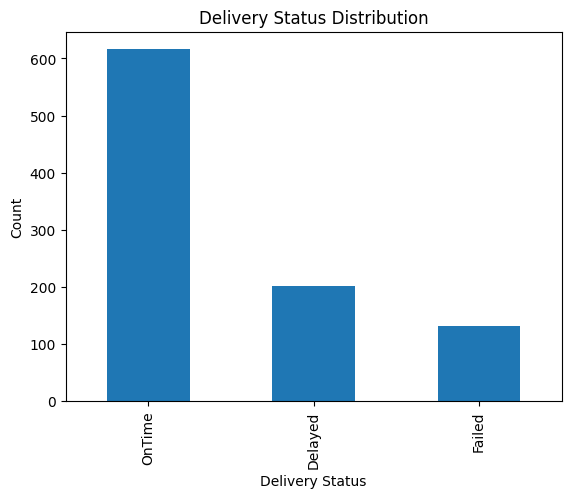

In [ ]:
import matplotlib.pyplot as plt

deliveries["delivery_status"].value_counts().plot(kind="bar")

plt.xlabel("Delivery Status")
plt.ylabel("Count")
plt.title("Delivery Status Distribution")

plt.show()

In [ ]:
from scipy.stats import ttest_ind

delayed = [202]
failed = [132]

t_stat, p_val = ttest_ind(delayed, failed)

print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: nan
P-value: nan


/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:6316: RuntimeWarning: invalid value encountered in scalar divide
  svar = ((n1 - 1) * v1 + (n2 - 1) * v2) / df


In [ ]:
import pandas as pd

vehicles = pd.read_csv('vehicles.csv')

vehicles['assigned_zone'] = vehicles['assigned_zone'].str.lower()

vehicles['battery_health_pct'] = vehicles['battery_health_pct'].fillna(
    vehicles['battery_health_pct'].mean()
)

vehicles['commission_date'] = pd.to_datetime(
    vehicles['commission_date']
)
vehicles.head()

,vehicle_id,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
0,V001,EV,north,2024-12-28 23:48:00,71.800000,56928,Active,v2.2
1,V002,EV,airport,2024-04-21 16:14:00,67.900000,159368,InRepair,v2.2
2,V003,CargoVan,north,2025-11-24 23:59:00,91.700000,219359,Active,v2.1
3,V004,Hybrid,riverside,2024-06-07 13:21:00,76.785345,36310,Active,v2.2
4,V005,CargoVan,west,2025-11-15 11:08:00,58.600000,146638,Active,v2.2


In [ ]:
risk_vehicles = vehicles[
    (vehicles['battery_health_pct'] < 60) &
    (vehicles['odometer_km'] > 140000)
]

risk_vehicles.head()

,vehicle_id,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
4,V005,CargoVan,west,2025-11-15 11:08:00,58.6,146638,Active,v2.2
66,V067,Hybrid,ctr,2025-11-15 00:12:00,57.3,176145,Active,v2.0
90,V091,Hybrid,east,2025-08-24 05:20:00,58.5,172956,Active,v1.9
107,V108,Diesel,airport,2025-01-31 06:29:00,54.6,141290,InRepair,v1.9


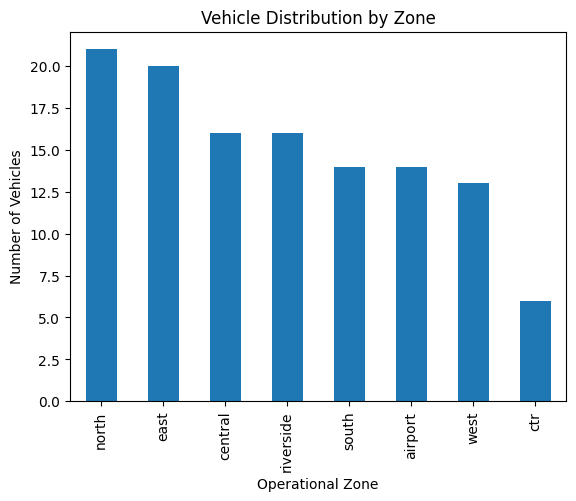

In [ ]:
import matplotlib.pyplot as plt

vehicles['assigned_zone'].value_counts().plot(kind='bar')

plt.title('Vehicle Distribution by Zone')
plt.xlabel('Operational Zone')
plt.ylabel('Number of Vehicles')

plt.show()

In [ ]:
deliveries = pd.read_csv('deliveries.csv')

deliveries['delivery_status'].value_counts()

,count
delivery_status,
OnTime,616
Delayed,202
Failed,132


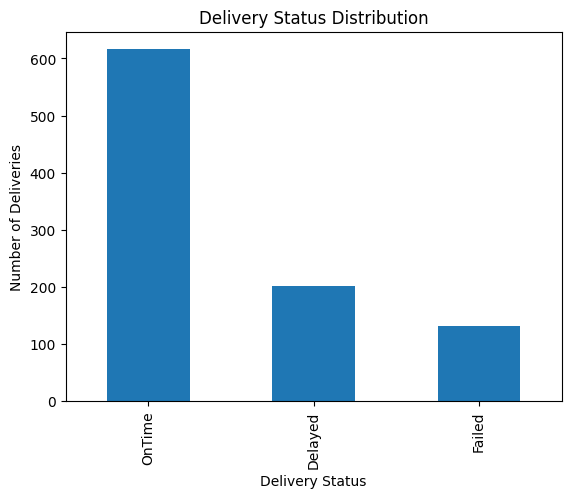

In [ ]:
import matplotlib.pyplot as plt

deliveries['delivery_status'].value_counts().plot(kind='bar')

plt.title('Delivery Status Distribution')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Deliveries')

plt.show()

In [ ]:
complaints = pd.read_csv('complaints.csv')

complaints.head()

,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
3,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
4,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18


In [ ]:
complaints.columns

Index(['complaint_id', 'customer_id', 'order_id', 'complaint_type', 'channel',
       'severity', 'created_at', 'status', 'resolution_days',
       'compensation_amount'],
      dtype='object')

In [ ]:
complaints.head()

,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
3,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
4,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18


In [ ]:
complaints['complaint_type'].value_counts()

,count
complaint_type,
Delay,101
MissedPickup,64
AppIssue,53
DriverBehaviour,51
SupportExperience,20
Billing,16
Damage,15


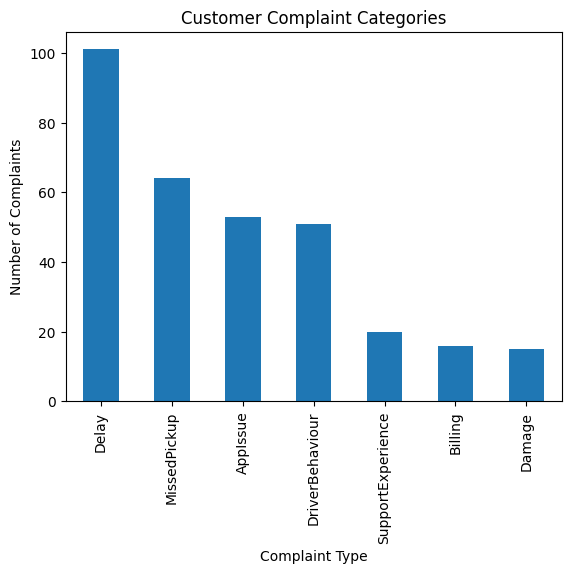

In [ ]:
import matplotlib.pyplot as plt

complaints['complaint_type'].value_counts().plot(kind='bar')

plt.title('Customer Complaint Categories')
plt.xlabel('Complaint Type')
plt.ylabel('Number of Complaints')

plt.show()